# Hypothesis Testing

### Import Libraries

In [1]:
import sys
from pathlib import Path
# Ensure project root is on sys.path so `import src` works when notebook is run from `notebooks/`
proj_root = Path.cwd().resolve().parent
proj_root_str = str(proj_root)
if proj_root_str not in sys.path:
    sys.path.insert(0, proj_root_str)
print('Added to sys.path:', proj_root_str)

Added to sys.path: C:\Users\teMelkishi\Desktop\projects\tenx\projects\insurance-risk-analytics


In [2]:
import numpy as np
from src.data_loader import (
    load_cleaned_data,
)

from src.hypothesis_tests import (
    plot_statistical_distribution,
    plot_poisson_distribution,
    chi_squared_claim_frequency_test,
    plot_chi_squared,
    plot_numerical_comparison,
    t_test,
    anova_test,
    interpret_decision,
    print_test_header,
    select_postalcodes_with_claims
)

#### Load data

In [3]:
df = load_cleaned_data(file_path="../data/processed/insurance_data.csv")
df.head()

INFO:src.data_loader:Loading cleaned data from: ../data/processed/insurance_data.csv
C:\Users\teMelkishi\Desktop\projects\tenx\projects\insurance-risk-analytics\src\data_loader.py:88: DtypeWarning: Columns (0: CapitalOutstanding) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(path, parse_dates=parse_dates)
INFO:src.data_loader:✅ Cleaned data loaded successfully! Shape: (989483, 47)
INFO:src.data_loader:Columns: ['UnderwrittenCoverID', 'PolicyID', 'TransactionMonth', 'IsVATRegistered', 'LegalType', 'Title', 'Language', 'Bank', 'AccountType', 'MaritalStatus', 'Gender', 'Country', 'Province', 'PostalCode', 'MainCrestaZone', 'SubCrestaZone', 'ItemType', 'mmcode', 'VehicleType', 'RegistrationYear', 'make', 'Model', 'Cylinders', 'cubiccapacity', 'kilowatts', 'bodytype', 'NumberOfDoors', 'VehicleIntroDate', 'AlarmImmobiliser', 'TrackingDevice', 'CapitalOutstanding', 'NewVehicle', 'SumInsured', 'TermFrequency', 'CalculatedPremiumPerTerm', 'ExcessSe

,UnderwrittenCoverID,PolicyID,TransactionMonth,IsVATRegistered,LegalType,Title,Language,Bank,AccountType,MaritalStatus,...,CoverType,CoverGroup,Section,Product,StatutoryClass,StatutoryRiskType,TotalPremium,TotalClaims,Margin,LossRatio
0,145249,12827,2015-03-01,True,Close Corporation,Mr,English,First National Bank,Current account,Not specified,...,Windscreen,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,21.929825,0.0,21.929825,0.0
1,145249,12827,2015-05-01,True,Close Corporation,Mr,English,First National Bank,Current account,Not specified,...,Windscreen,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,21.929825,0.0,21.929825,0.0
2,145249,12827,2015-07-01,True,Close Corporation,Mr,English,First National Bank,Current account,Not specified,...,Windscreen,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,0.000000,0.0,0.000000,0.0
3,145255,12827,2015-05-01,True,Close Corporation,Mr,English,First National Bank,Current account,Not specified,...,Own Damage,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,512.848070,0.0,512.848070,0.0
4,145255,12827,2015-07-01,True,Close Corporation,Mr,English,First National Bank,Current account,Not specified,...,Own Damage,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,0.000000,0.0,0.000000,0.0


## statistical distribution

In [4]:
severity_df = df[df['TotalClaims'] > 0] # Focus on claim severity (non-zero claims)

#### Claim Frequency

In [5]:
# policies and claims
df['HasClaim'] = (df['TotalClaims'] > 0).astype(int)

In [6]:
print(df['HasClaim'].value_counts())
print(f"Total Claims found: {df['HasClaim'].sum()}")

HasClaim
0    986723
1      2760
Name: count, dtype: int64
Total Claims found: 2760


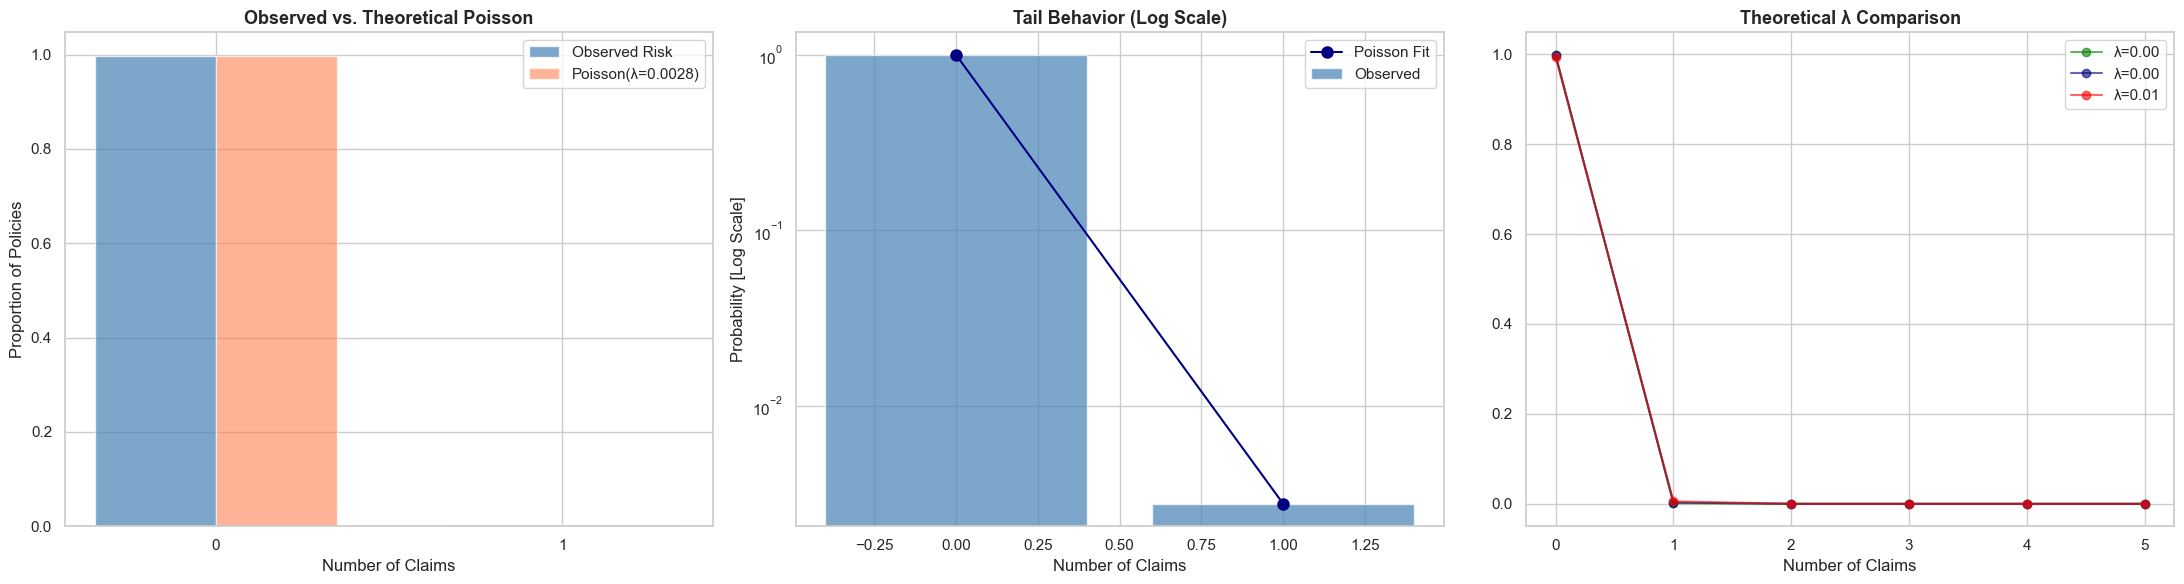

=== Poisson Analysis Summary for HasClaim ===
Overall λ (Claim Frequency): 0.00279
Overall Variance:           0.00278
Ratio (Var/Mean):           0.997 (Ideally ≈ 1 for Poisson)

Business Insight: Higher λ indicates a segment with higher service costs and risk frequency (Slide 8).


In [7]:
plot_poisson_distribution(df, column='HasClaim', title_suffix="- Claim Frequency Analysis (Poisson Distribution Fit)")

**Observation:** It means on average, for every 1,000 policies, We only expect 2.8 claims

#### Claim Severity

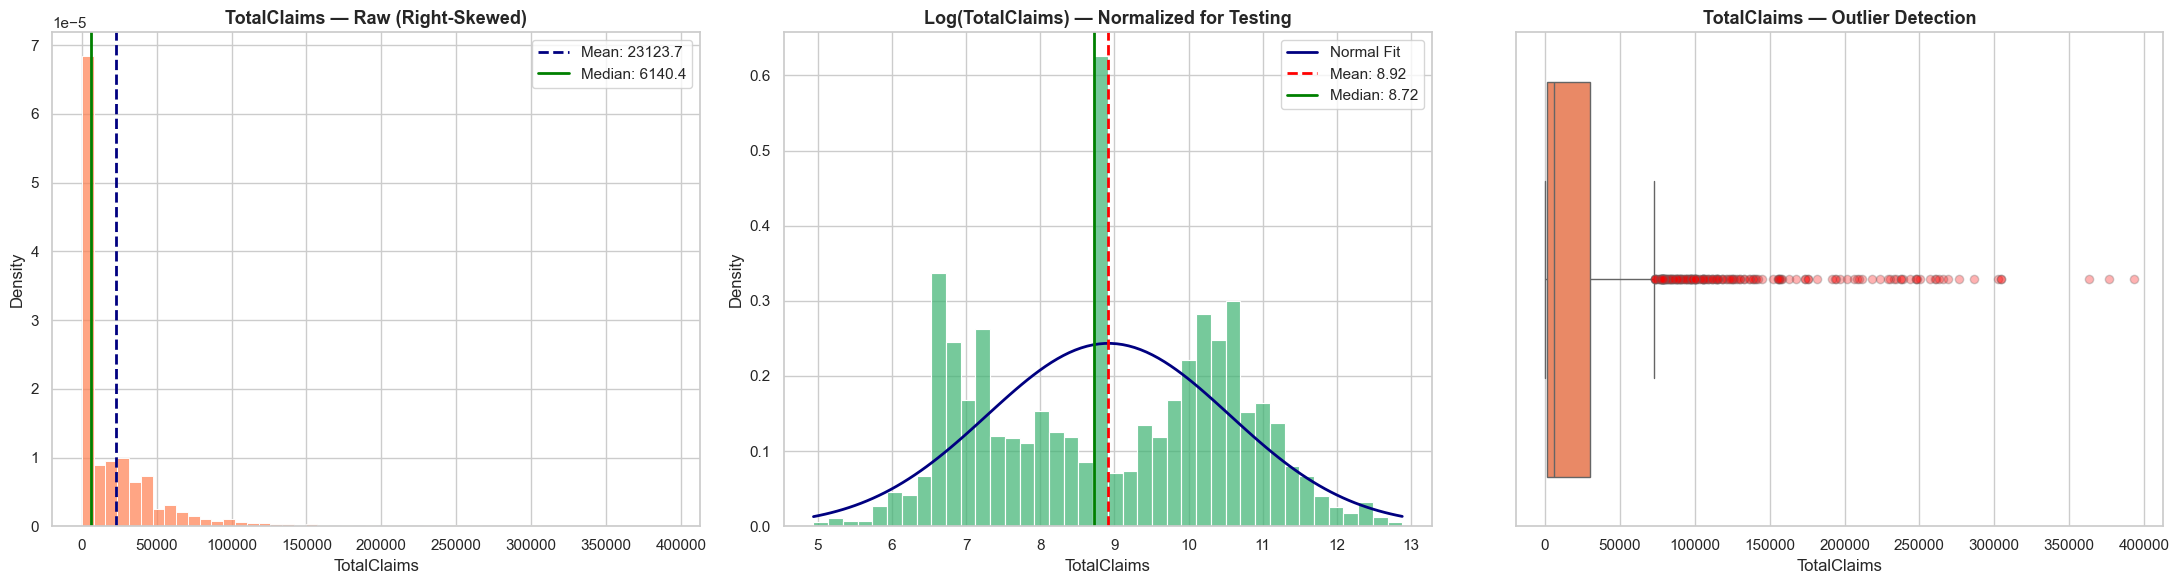

=== Analytical Summary for TotalClaims ===
Mean:     23123.66  ← Pulled RIGHT (Slide 6)
Median:   6140.35  ← More representative of "Typical" risk
Skewness: 3.895  (High Skew)
Outliers: 183 events detected above 73286.75 (IQR Method)
Max Risk: 393092.11 (Highest single value)

ADVICE: Use Log-transformed data for T-tests/ANOVA to satisfy Normality assumptions.


In [8]:

plot_statistical_distribution(severity_df, column='TotalClaims', title_suffix="- Claim Severity Analysis (Mean vs Median vs Mode)")

#### Margin 

c:\Users\teMelkishi\Desktop\projects\tenx\projects\insurance-risk-analytics\.venv\Lib\site-packages\pandas\core\arraylike.py:402: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


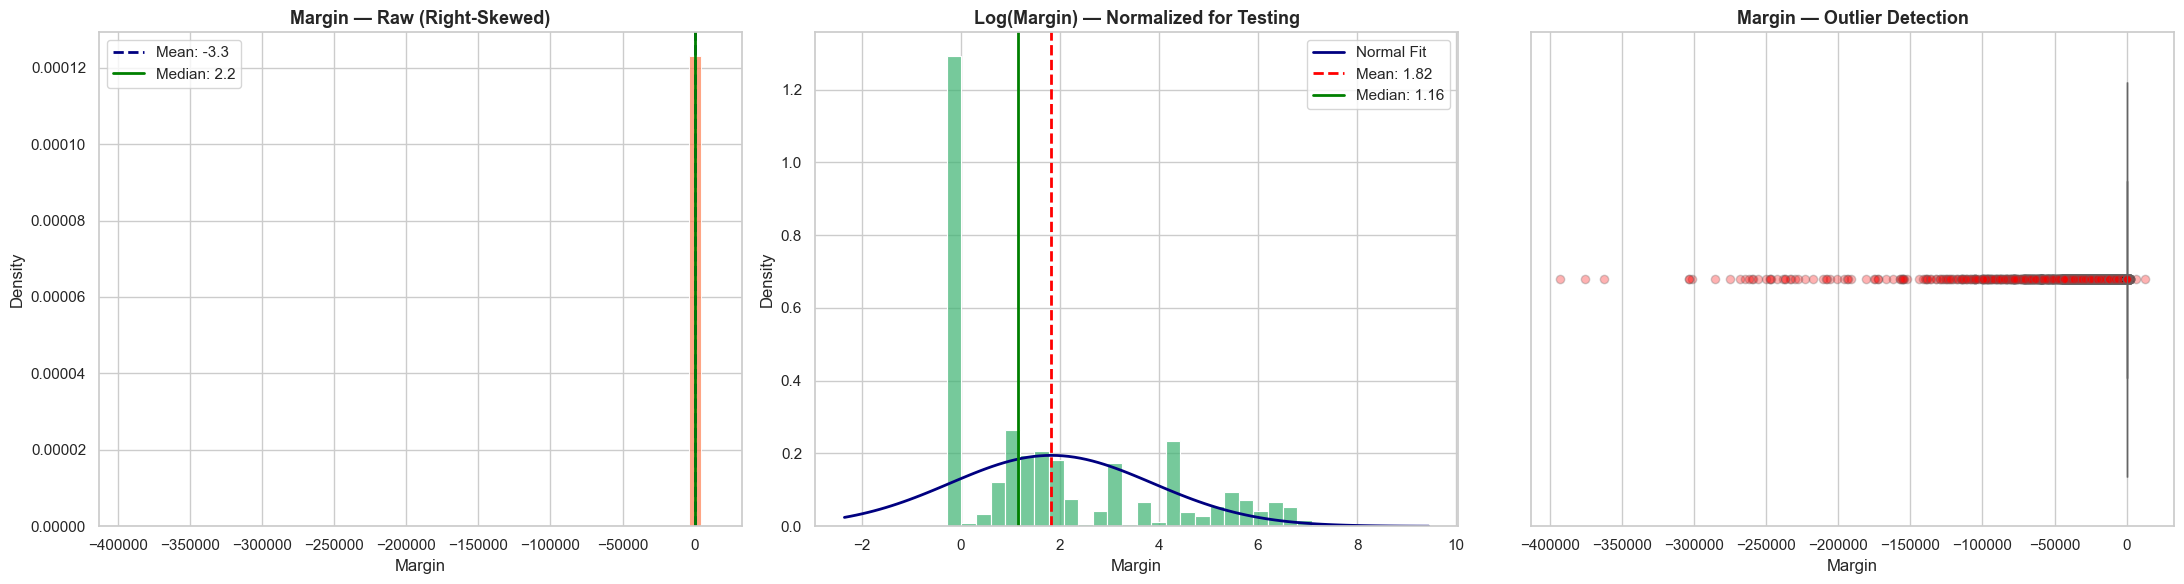

=== Analytical Summary for Margin ===
Mean:     -3.34  ← Pulled LEFT (Slide 6)
Median:   2.18  ← More representative of "Typical" risk
Skewness: -70.563  (High Skew)
Outliers: 204659 events detected above 54.82 (IQR Method)
Max Risk: 12644.25 (Highest single value)

ADVICE: Use Log-transformed data for T-tests/ANOVA to satisfy Normality assumptions.


In [9]:
plot_statistical_distribution(df, column='Margin', title_suffix='- Profitability Analysis')

## A/B Hypothesis Testing

### Hypotheses to Test

**Hypothesis 1: Provinces**  
- **H₀**: There are no risk differences across provinces (Claim Frequency is independent of Province).  
- **H₁**: There are significant risk differences across provinces.

**Hypothesis 2: Zip Codes (Risk)**  
- **H₀**: There are no risk differences between zip codes.  
- **H₁**: There are significant risk differences between zip codes.

**Hypothesis 3: Zip Codes (Margin)**  
- **H₀**: There is no significant margin difference between zip codes.  
- **H₁**: There is a significant margin difference between zip codes.

**Hypothesis 4: Gender**  
- **H₀**: There is no significant risk difference between Women and Men.  
- **H₁**: There is a significant risk difference between Women and Men.

### **Hypothesis 1: Provinces**

**Selected KPI** : *Claim Frequency*

**Best Test** : *Chi-Squared Test*

**Reason**: 
  - Provinces often differ in how often accidents or claims happen due to factors like road conditions, weather, traffic density, and driving culture. 

  - Frequency is usually the first and strongest signal of geographic risk differences. Severity might vary too, but frequency is more stable and directly tied to "risk differences across provinces".


                       CHI-SQUARED TEST - CLAIM FREQUENCY             
H₀: No risk difference in Claim Frequency across Province
H₁: There is a significant difference in Claim Frequency
Chi² Statistic : 114.6195
p-value        : 0.000000
DECISION: p = 0.000000 < α (0.05) → REJECT H₀


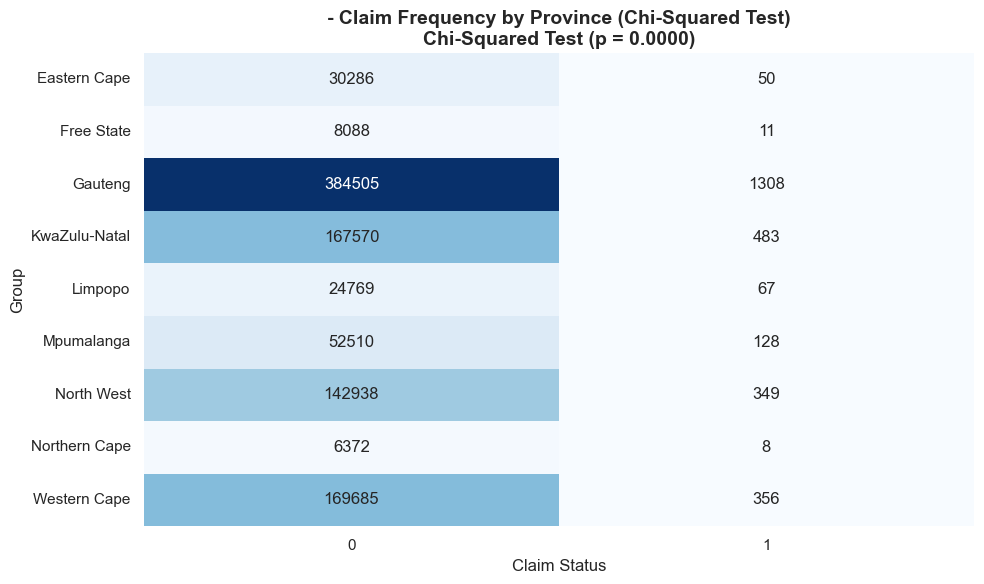

(np.float64(4.267218852473968e-21),
 True,
 HasClaim            0     1
 Province                   
 Eastern Cape    30286    50
 Free State       8088    11
 Gauteng        384505  1308
 KwaZulu-Natal  167570   483
 Limpopo         24769    67
 Mpumalanga      52510   128
 North West     142938   349
 Northern Cape    6372     8
 Western Cape   169685   356)

In [10]:
chi_squared_claim_frequency_test(df, group_col='Province', claim_col='HasClaim', title="- Claim Frequency by Province (Chi-Squared Test)")

### **Hypothesis 2: Zip Codes (Risk)**

**Selected KPI** : *Claim Severity*

**Best Test** : *T-test (2 zips) or ANOVA (multiple zips)*

**Reason**: 
  - Zip codes (postal areas) are smaller and more granular. Differences here are often driven by how expensive claims are — e.g., higher repair costs in urban areas, theft rates, flood risks, or cost of living. 

  - Claim Severity captures localized cost variations better than frequency in many cases.

In [11]:
# calculate per-policy claim severity (only for policies with a claim) and compute average
df['ClaimSeverity'] = df['TotalClaims'].where(df['TotalClaims'] > 0, np.nan)
avg_claim_amount = df['ClaimSeverity'].mean()
print(f"Average claim amount (severity): {avg_claim_amount:.2f}")

Average claim amount (severity): 23123.66


In [12]:
# === DIAGNOSTIC: Check claims per postal code in Gauteng ===
province = "Gauteng"

summary = df[df['Province'] == province].groupby('PostalCode').agg(
    total_policies=('PostalCode', 'count'),
    num_claims=('ClaimSeverity', 'count'),      # Only policies with claims
    mean_severity=('ClaimSeverity', 'mean'),
    mean_totalclaims=('TotalClaims', 'mean')
).round(2)

summary = summary.sort_values('num_claims', ascending=False)

print(f"Top 15 Postal Codes in {province} by Number of Claims:")
print(summary.head(15))

print(f"\nTotal postal codes with at least 1 claim: {(summary['num_claims'] > 0).sum()}")

Top 15 Postal Codes in Gauteng by Number of Claims:
            total_policies  num_claims  mean_severity  mean_totalclaims
PostalCode                                                             
2000                133258         486       19196.41             70.01
122                  49171         210       18162.03             77.57
1863                  8651          44       30915.85            157.24
152                   9423          32       10755.04             36.52
1724                 10107          25       22034.36             54.50
2196                  3240          18       62310.88            346.17
183                   2515          13       28438.81            147.00
2198                  3346          13       47896.37            186.09
1                     5341          12       25631.95             57.59
2090                  3462          12       14543.38             50.41
2037                  2424          11       63735.88            289.23
1522        


Remaining rows after filtering: 385813
Unique postal codes: 257
Valid postal codes: 6

✅ Selected postal codes

Postal Code      : 1724
Policies         : 10107
Claims           : 25
Claim Frequency  : 0.0025
Mean Severity    : 22034.36
Std Severity     : 21817.09

Postal Code      : 152
Policies         : 9423
Claims           : 32
Claim Frequency  : 0.0034
Mean Severity    : 10755.04
Std Severity     : 24832.50


                           INDEPENDENT SAMPLES T-TEST                 
Sample Size - 1724: 25 | 152: 32
⚠️ Warning: One or both groups have small sample size (< 30)
H₀: Mean ClaimSeverity is the same for 1724 and 152
H₁: Mean ClaimSeverity differs
T-statistic : 1.8223
p-value     : 0.073924
DECISION: p = 0.0739 ≥ α (0.05) → FAIL TO REJECT H₀


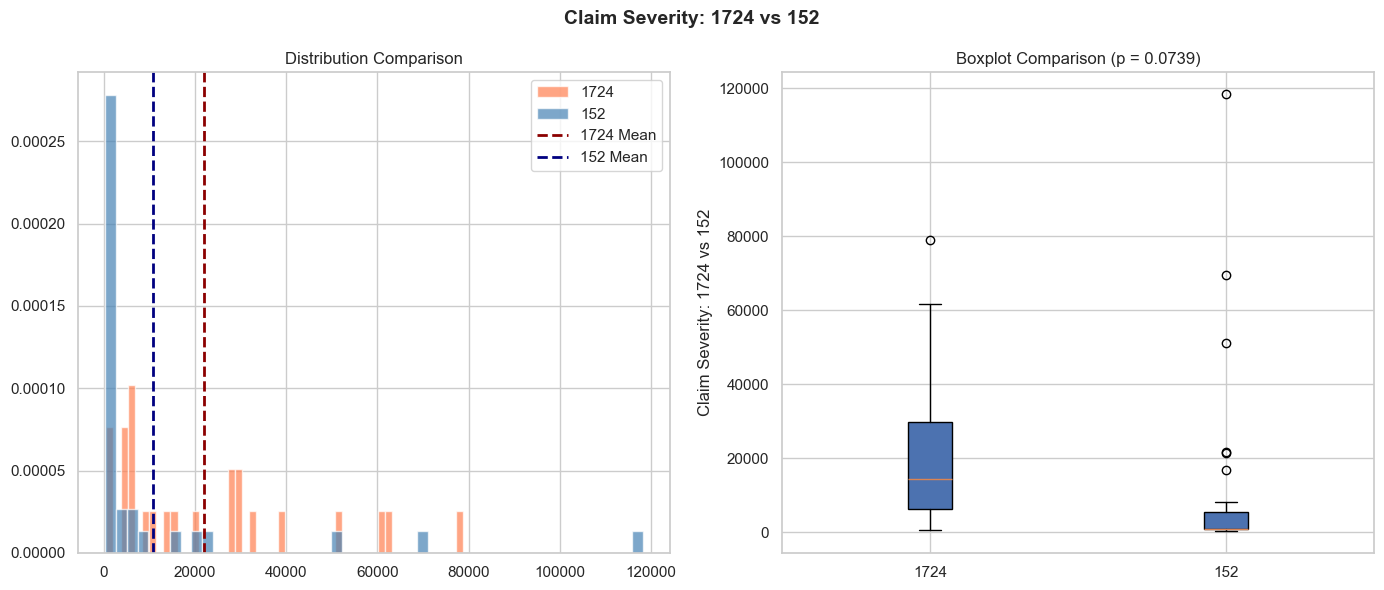

In [13]:
# 1. Make sure ClaimSeverity exists
if 'ClaimSeverity' not in df.columns or df['ClaimSeverity'].isna().all():
    df['ClaimSeverity'] = np.where(df['TotalClaims'] > 0, df['TotalClaims'], np.nan)

# 2. Select good postal codes
zip1, zip2 = select_postalcodes_with_claims(df, province="Gauteng", min_claims=15)

if zip1 and zip2:
    # 3. Run T-test
    p_value, rejected = t_test(
        df=df,
        group_col='PostalCode',
        value_col='ClaimSeverity',
        group_a=zip1,
        group_b=zip2,
        title=f"Claim Severity: {zip1} vs {zip2}"
    )

### **Hypothesis 3: Zip Codes (Margin)**

**Selected KPI** : *Margin*

**Best Test** : *ANOVA (multiple zips)*

**Reason**: 
  - The hypothesis is explicitly about profitability (Margin = Premiums - Claims). So we must use Margin directly.

In [14]:
# Remove extreme outliers (e.g., bottom/top 1%)
lower = df['Margin'].quantile(0.01)
upper = df['Margin'].quantile(0.99)

df_clean = df[(df['Margin'] >= lower) & (df['Margin'] <= upper)].copy()

print(f"Removed {len(df) - len(df_clean)} extreme outliers")

Removed 12901 extreme outliers



                                 ONE-WAY ANOVA                        
Testing 8 largest groups (min 50 samples each)
H₀: Mean Margin is the same across PostalCode
H₁: At least one group differs
F-statistic : 108.5046
p-value     : 0.000000
DECISION: p = 0.000000 < α (0.05) → REJECT H₀


INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


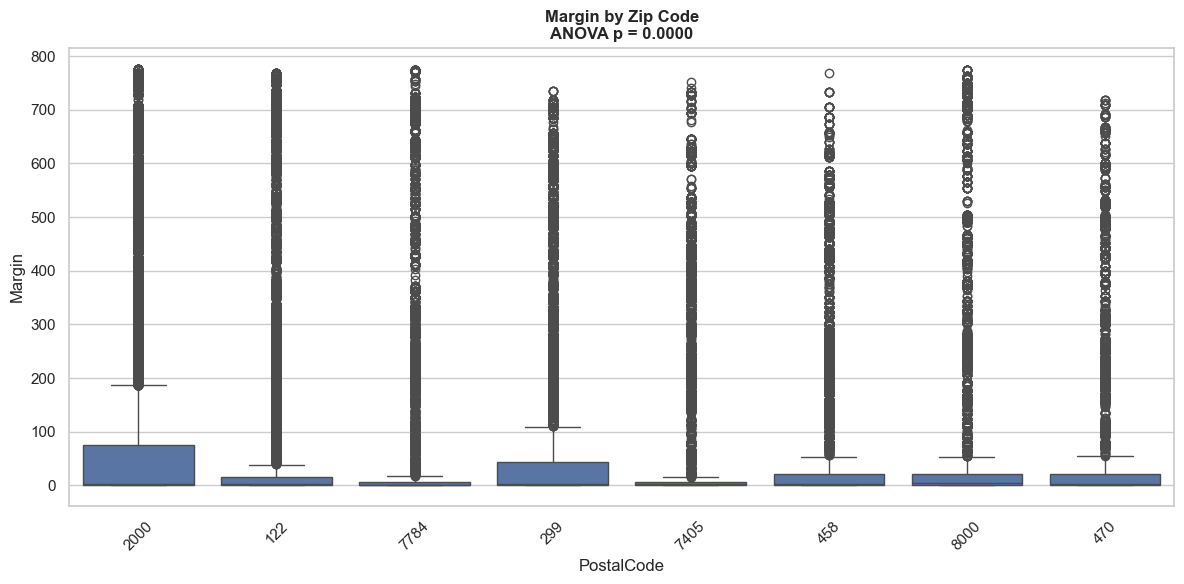

(np.float64(1.6356847027025414e-159), True)

In [15]:
anova_test(
    df_clean,
    group_col="PostalCode",
    value_col="Margin",
    title="Margin by Zip Code",
    max_groups=8,
    min_count=50,
)

### **Hypothesis 4: Gender**  

**Selected KPI** : *Claim Frequency*

**Best Test** : *Chi-Squared Test*

**Reason**: 
  - Gender differences in driving behavior usually affect frequency more than severity


                       CHI-SQUARED TEST - CLAIM FREQUENCY             
→ Filtered out categories: ['Unspecified']
H₀: No risk difference in Claim Frequency across Gender
H₁: There is a significant difference in Claim Frequency
Chi² Statistic : 6.9695
p-value        : 0.030662
DECISION: p = 0.030662 < α (0.05) → REJECT H₀


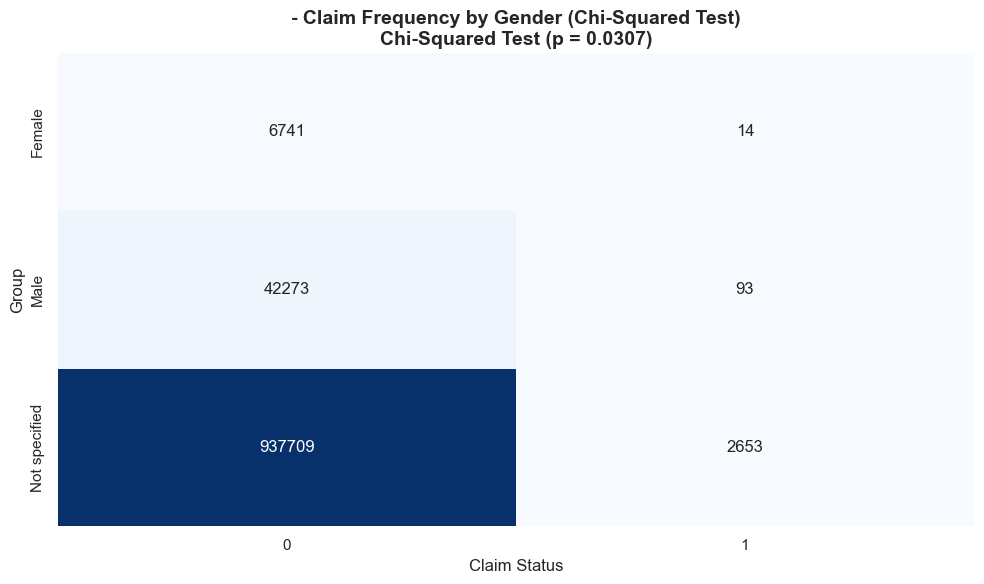

(np.float64(0.03066173631282701),
 True,
 HasClaim            0     1
 Gender                     
 Female           6741    14
 Male            42273    93
 Not specified  937709  2653)

In [16]:
chi_squared_claim_frequency_test(
    df,
    group_col="Gender",
    claim_col="HasClaim",
    drop_categories=["Unspecified"],
    title="- Claim Frequency by Gender (Chi-Squared Test)",
)